# PS0_Secondary — Secondary I_bias Sweeps
## Option C: HH Delay-Directed Orbit Selection
### HHSMC Project — Issue #8

Runs coarse (K, τ) sweeps at **I_bias = 8.0 μA/cm²** and **I_bias = 12.0 μA/cm²**
to confirm that limit-cycle proliferation (207 orbit types at 10.0 μA/cm²) is not
specific to a single bias current.

**Grid:** K ∈ [0, 2] (51 values, step 0.04) × τ ∈ [1, 200] ms (50 log-spaced)
= **2,550 points per bias value** (~8 min each on A100, ~18 min on CPU).

**Outputs (saved to `PS0_secondary/`):**
- `PS0_secondary_Ibias_8p0.npz` / `PS0_secondary_Ibias_12p0.npz` — raw grids
- `PS0_secondary_orbit_types_Ibias_*.json` — orbit catalogues
- `PS0_secondary_summary.json` — comparison table (periodic%, orbit types, categories)
- `PS0_secondary_comparison.png` — 2×3 figure for paper Appendix

All functions are **copied verbatim from PS0_OrbitCatalogue** to guarantee
identical simulation, classification, and clustering logic.

## CELL 1 — Setup and Imports

In [1]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import json, os, time, warnings
from datetime import datetime
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from collections import Counter

# --- Google Drive Mount ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PS0_DIR    = '/content/drive/My Drive/HHSMC/full_study/PS0_orbit_catalogue'
    OUTPUT_DIR = '/content/drive/My Drive/HHSMC/full_study/PS0_secondary'
    ON_COLAB = True
except ImportError:
    PS0_DIR    = './PS0_results'
    OUTPUT_DIR = './PS0_secondary_results'
    ON_COLAB = False

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"PS0 primary dir : {PS0_DIR}")
print(f"Output dir      : {OUTPUT_DIR}")
print(f"Started         : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Mounted at /content/drive
PS0 primary dir : /content/drive/My Drive/HHSMC/full_study/PS0_orbit_catalogue
Output dir      : /content/drive/My Drive/HHSMC/full_study/PS0_secondary
Started         : 2026-03-05 09:51:15


## CELL 2 — HH Model (V-shifted convention, rest = 0)
*Copied verbatim from PS0_OrbitCatalogue Cell 4.*

In [2]:
# --- Fixed biophysical parameters (identical to PS0) ---
C_M  = 1.0      # μF/cm²
G_NA = 120.0     # mS/cm²
G_K  = 36.0      # mS/cm²
G_L  = 0.3       # mS/cm²
E_NA = 115.0     # mV (V-shifted)
E_K  = -12.0     # mV (V-shifted)
E_L  = 10.6      # mV (V-shifted)
DT   = 0.01      # ms integration step

@njit
def alpha_m(V):
    x = 25.0 - V
    if abs(x) < 1e-7: return 1.0
    return 0.1 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_m(V):
    return 4.0 * np.exp(-V / 18.0)

@njit
def alpha_h(V):
    return 0.07 * np.exp(-V / 20.0)

@njit
def beta_h(V):
    return 1.0 / (np.exp((30.0 - V) / 10.0) + 1.0)

@njit
def alpha_n(V):
    x = 10.0 - V
    if abs(x) < 1e-7: return 0.1
    return 0.01 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_n(V):
    return 0.125 * np.exp(-V / 80.0)

@njit
def hh_rhs(V, m, h, n, I_total):
    I_Na = G_NA * m*m*m * h * (V - E_NA)
    I_K  = G_K  * n*n*n*n  * (V - E_K)
    I_L  = G_L  * (V - E_L)
    dV = (I_total - I_Na - I_K - I_L) / C_M
    dm = alpha_m(V) * (1.0 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1.0 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1.0 - n) - beta_n(V) * n
    return dV, dm, dh, dn

@njit
def hh_steady_state(V):
    am = alpha_m(V); bm = beta_m(V)
    ah = alpha_h(V); bh = beta_h(V)
    an = alpha_n(V); bn = beta_n(V)
    return am/(am+bm), ah/(ah+bh), an/(an+bn)

print("HH model defined (V-shifted, rest=0 mV)")

HH model defined (V-shifted, rest=0 mV)


## CELL 3 — Simulation Engine (HH + DFC, RK4)
*Copied verbatim from PS0_OrbitCatalogue Cell 6.*

In [3]:
@njit
def simulate_hh_dfc_full(I_bias, K, tau_ms, T_total_ms, dt=0.01,
                          T_transient_ms=0.0):
    """
    Simulate HH neuron with Pyragas DFC. Returns spike times, ISIs,
    and the full voltage trace for pattern analysis.
    Corrections: RC3 warm-start, DFC recomputed at each RK4 substep,
    L'Hopital limits in all rate functions.
    """
    n_steps = int(T_total_ms / dt)
    buf_size = max(int(tau_ms / dt), 1)

    V = 0.0
    m, h, n = hh_steady_state(V)

    # RC3 warm-start
    V_buf = np.zeros(buf_size)
    for ws in range(buf_size):
        I_total = I_bias
        dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)
        V2 = V+0.5*dt*dV1; m2 = m+0.5*dt*dm1; h2 = h+0.5*dt*dh1; n2 = n+0.5*dt*dn1
        dV2, dm2, dh2, dn2 = hh_rhs(V2, m2, h2, n2, I_total)
        V3 = V+0.5*dt*dV2; m3 = m+0.5*dt*dm2; h3 = h+0.5*dt*dh2; n3 = n+0.5*dt*dn2
        dV3, dm3, dh3, dn3 = hh_rhs(V3, m3, h3, n3, I_total)
        V4 = V+dt*dV3; m4 = m+dt*dm3; h4 = h+dt*dh3; n4 = n+dt*dn3
        dV4, dm4, dh4, dn4 = hh_rhs(V4, m4, h4, n4, I_total)
        V = V+(dt/6.0)*(dV1+2*dV2+2*dV3+dV4)
        m = min(max(m+(dt/6.0)*(dm1+2*dm2+2*dm3+dm4), 0.0), 1.0)
        h = min(max(h+(dt/6.0)*(dh1+2*dh2+2*dh3+dh4), 0.0), 1.0)
        n = min(max(n+(dt/6.0)*(dn1+2*dn2+2*dn3+dn4), 0.0), 1.0)
        V_buf[ws % buf_size] = V

    buf_idx = 0
    max_spikes = int(T_total_ms / 2) + 100
    spike_times_raw = np.empty(max_spikes)
    n_spikes_raw = 0
    V_prev = V
    subsample = 10
    n_trace = n_steps // subsample + 1
    V_trace = np.empty(n_trace)
    trace_idx = 0

    for step in range(n_steps):
        V_delayed = V_buf[buf_idx]
        I_ctrl = K * (V_delayed - V)
        I_total = I_bias + I_ctrl

        dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)
        Vk2 = V+0.5*dt*dV1; I2 = I_bias+K*(V_delayed-Vk2)
        mk2 = m+0.5*dt*dm1; hk2 = h+0.5*dt*dh1; nk2 = n+0.5*dt*dn1
        dV2, dm2, dh2, dn2 = hh_rhs(Vk2, mk2, hk2, nk2, I2)
        Vk3 = V+0.5*dt*dV2; I3 = I_bias+K*(V_delayed-Vk3)
        mk3 = m+0.5*dt*dm2; hk3 = h+0.5*dt*dh2; nk3 = n+0.5*dt*dn2
        dV3, dm3, dh3, dn3 = hh_rhs(Vk3, mk3, hk3, nk3, I3)
        Vk4 = V+dt*dV3; I4 = I_bias+K*(V_delayed-Vk4)
        mk4 = m+dt*dm3; hk4 = h+dt*dh3; nk4 = n+dt*dn3
        dV4, dm4, dh4, dn4 = hh_rhs(Vk4, mk4, hk4, nk4, I4)

        V_new = V+(dt/6.0)*(dV1+2*dV2+2*dV3+dV4)
        m_new = min(max(m+(dt/6.0)*(dm1+2*dm2+2*dm3+dm4), 0.0), 1.0)
        h_new = min(max(h+(dt/6.0)*(dh1+2*dh2+2*dh3+dh4), 0.0), 1.0)
        n_new = min(max(n+(dt/6.0)*(dn1+2*dn2+2*dn3+dn4), 0.0), 1.0)

        V_buf[buf_idx] = V_new
        buf_idx = (buf_idx + 1) % buf_size

        if V_prev <= 0.0 and V_new > 0.0:
            if n_spikes_raw < max_spikes:
                spike_times_raw[n_spikes_raw] = step * dt
                n_spikes_raw += 1

        if step % subsample == 0 and trace_idx < n_trace:
            V_trace[trace_idx] = V_new
            trace_idx += 1

        V_prev = V_new
        V = V_new; m = m_new; h = h_new; n = n_new

    spike_times = spike_times_raw[:n_spikes_raw]
    V_trace = V_trace[:trace_idx]

    if T_transient_ms > 0:
        mask = spike_times >= T_transient_ms
        spike_times_analysis = spike_times[mask]
    else:
        spike_times_analysis = spike_times

    if len(spike_times_analysis) >= 2:
        isi_array = np.diff(spike_times_analysis)
    else:
        isi_array = np.empty(0)

    return spike_times_analysis, isi_array, V_trace

print("Simulation engine defined.")

Simulation engine defined.


## CELL 4 — ISI Pattern Analysis and Classification
*Copied verbatim from PS0_OrbitCatalogue Cell 8.*

In [4]:
@njit
def isi_cv(isi_array):
    if len(isi_array) < 3: return -1.0
    mu = np.mean(isi_array)
    if mu < 1e-10: return -1.0
    return np.std(isi_array) / mu


def detect_pattern_period(isis, max_period_spikes=12):
    if len(isis) < 6:
        return 1, isis[:1] if len(isis) > 0 else np.array([0.0]), 0.0
    isis = np.array(isis, dtype=np.float64)
    n = len(isis)
    best_len = 1; best_conf = 0.0; best_pattern = isis[:1]
    for p in range(1, min(max_period_spikes + 1, n // 3 + 1)):
        n_compare = min(n - p, 3 * p)
        if n_compare < p: continue
        diffs = np.zeros(n_compare)
        for i in range(n_compare):
            diffs[i] = abs(isis[i] - isis[i + p])
        med_diff = np.median(diffs)
        med_isi  = np.median(isis)
        if med_isi > 0:
            relative_error = med_diff / med_isi
        else:
            continue
        conf = max(0.0, 1.0 - relative_error * 10.0)
        if conf > best_conf and conf > 0.8:
            best_len = p; best_conf = conf
            pattern = np.zeros(p); count = 0
            for rep in range(n // p):
                start = rep * p
                if start + p <= n:
                    pattern += isis[start:start+p]; count += 1
            if count > 0: pattern /= count
            best_pattern = pattern
    if best_len == 1 and len(isis) >= 3:
        cv = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else 999
        if cv < 0.02:
            best_conf = 1.0; best_pattern = np.array([np.mean(isis)])
    return best_len, best_pattern, best_conf


def classify_dynamics(isis, spike_times, V_trace, T_analysis_ms):
    result = {
        'class': 'unknown', 'n_spikes': len(spike_times),
        'isi_cv': -1.0, 'isi_mean': 0.0, 'isi_std': 0.0,
        'firing_rate': 0.0, 'pattern_length': 0, 'pattern_isis': [],
        'pattern_period_ms': 0.0, 'fingerprint': np.zeros(6),
    }
    if len(spike_times) < 5:
        result['class'] = 'silent'; return result
    if V_trace is not None and len(V_trace) > 100:
        last_quarter = V_trace[3*len(V_trace)//4:]
        if np.mean(last_quarter) > 30.0 and np.std(last_quarter) < 5.0:
            result['class'] = 'depol_block'; return result
    cv = isi_cv(isis)
    result['isi_cv'] = cv
    result['isi_mean']    = float(np.mean(isis))
    result['isi_std']     = float(np.std(isis))
    result['firing_rate'] = len(spike_times) / (T_analysis_ms / 1000.0)
    if cv < 0:
        result['class'] = 'insufficient'; return result
    if cv < 0.02:
        p_len, p_isis, p_conf = detect_pattern_period(isis)
        result['pattern_length']   = p_len
        result['pattern_isis']     = p_isis.tolist()
        result['pattern_period_ms']= float(np.sum(p_isis))
        result['class'] = 'tonic' if p_len == 1 else f'periodic_p{p_len}'
    elif cv < 0.10:
        p_len, p_isis, p_conf = detect_pattern_period(isis)
        result['pattern_length']   = p_len
        result['pattern_isis']     = p_isis.tolist()
        result['pattern_period_ms']= float(np.sum(p_isis))
        result['class'] = f'periodic_p{p_len}' if p_conf > 0.7 else 'quasi_periodic'
    elif cv < 0.15:
        result['class'] = 'quasi_periodic'
    else:
        result['class'] = 'chaotic'
    isi_range = float(np.max(isis) - np.min(isis)) if len(isis) > 0 else 0.0
    result['fingerprint'] = np.array([
        result['isi_mean'], result['isi_cv'], float(result['pattern_length']),
        result['pattern_period_ms'], result['firing_rate'], isi_range,
    ])
    return result

print("ISI analysis and classification defined.")

ISI analysis and classification defined.


## CELL 5 — Dense Sweep Function
*Copied verbatim from PS0_OrbitCatalogue Cell 10.*

In [5]:
def run_dense_sweep(I_bias, K_range, tau_range,
                    T_sim=3000.0, T_transient=500.0):
    n_K = len(K_range); n_tau = len(tau_range); total = n_K * n_tau
    T_analysis = T_sim - T_transient

    print(f"Dense Sweep: {n_K} x {n_tau} = {total} grid points")
    print(f"  I_bias = {I_bias:.1f} uA/cm2")
    print(f"  K:   [{K_range[0]:.3f}, {K_range[-1]:.3f}] ({n_K} values)")
    print(f"  tau: [{tau_range[0]:.1f}, {tau_range[-1]:.1f}] ms ({n_tau} values)")
    print(f"  T_sim = {T_sim:.0f} ms, T_transient = {T_transient:.0f} ms")

    print("JIT warmup...", end=" ", flush=True)
    _ = simulate_hh_dfc_full(I_bias, 0.5, 50.0, 200.0, DT, 100.0)
    print("done.")

    class_map = {'silent':0,'depol_block':1,'tonic':2,'quasi_periodic':3,
                 'chaotic':4,'insufficient':5,'unknown':6}
    results_grid = [[None]*n_tau for _ in range(n_K)]
    class_grid    = np.full((n_K, n_tau), -1, dtype=np.int32)
    isi_mean_grid = np.full((n_K, n_tau), np.nan)
    cv_grid       = np.full((n_K, n_tau), np.nan)
    fr_grid       = np.full((n_K, n_tau), np.nan)

    t0 = time.time(); done = 0
    for ik, K_val in enumerate(K_range):
        for it, tau_val in enumerate(tau_range):
            spk, isis, V_trace = simulate_hh_dfc_full(
                I_bias, K_val, tau_val, T_sim, DT, T_transient)
            result = classify_dynamics(isis, spk, V_trace, T_analysis)
            result['K'] = float(K_val); result['tau_ms'] = float(tau_val)
            results_grid[ik][it] = result
            cls = result['class']
            if cls in class_map:
                class_grid[ik, it] = class_map[cls]
            elif cls.startswith('periodic_p'):
                class_grid[ik, it] = 10 + int(cls.split('_p')[1])
            else:
                class_grid[ik, it] = 6
            isi_mean_grid[ik, it] = result['isi_mean']
            cv_grid[ik, it]       = result['isi_cv']
            fr_grid[ik, it]       = result['firing_rate']
            done += 1
            if done % 500 == 0:
                elapsed = time.time() - t0
                eta = (total - done) / (done / elapsed)
                print(f"  [{done}/{total}] {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining",
                      flush=True)

    elapsed = time.time() - t0
    print(f"Sweep complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    class_counts = Counter()
    for ik in range(n_K):
        for it in range(n_tau):
            class_counts[results_grid[ik][it]['class']] += 1
    print("\nClassification summary:")
    for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
        print(f"  {cls:20s}: {count:5d} ({100.0*count/total:5.1f}%)")

    summary = {'I_bias': I_bias, 'n_K': n_K, 'n_tau': n_tau,
               'total_points': total, 'T_sim': T_sim, 'T_transient': T_transient,
               'class_counts': dict(class_counts), 'elapsed_s': elapsed}
    return results_grid, class_grid, isi_mean_grid, cv_grid, fr_grid, summary

print("Sweep function defined.")

Sweep function defined.


## CELL 6 — Orbit Fingerprint Clustering
*Copied verbatim from PS0_OrbitCatalogue Cell 12.*

In [6]:
def cluster_orbits(results_grid, K_range, tau_range,
                   min_isi_separation=2.0, linkage_method='average'):
    n_K = len(K_range); n_tau = len(tau_range)
    periodic_points = []
    for ik in range(n_K):
        for it in range(n_tau):
            r = results_grid[ik][it]
            cls = r['class']
            if cls == 'tonic' or cls.startswith('periodic_p'):
                periodic_points.append({
                    'ik': ik, 'it': it, 'K': r['K'], 'tau_ms': r['tau_ms'],
                    'class': cls, 'isi_mean': r['isi_mean'], 'isi_cv': r['isi_cv'],
                    'pattern_length': r['pattern_length'],
                    'pattern_period_ms': r['pattern_period_ms'],
                    'pattern_isis': r['pattern_isis'],
                    'firing_rate': r['firing_rate'],
                    'fingerprint': r['fingerprint'],
                })
    n_periodic = len(periodic_points)
    print(f"\nOrbit clustering: {n_periodic} periodic points")
    if n_periodic == 0:
        print("  No periodic points found!"); return [], {}

    fp_matrix = np.zeros((n_periodic, 3))
    for i, p in enumerate(periodic_points):
        fp_matrix[i, 0] = p['isi_mean']
        fp_matrix[i, 1] = p['pattern_period_ms'] * 0.5
        fp_matrix[i, 2] = p['pattern_length'] * 5.0

    if n_periodic > 1:
        dists = pdist(fp_matrix, metric='euclidean')
        Z = linkage(dists, method=linkage_method)
        labels = fcluster(Z, t=min_isi_separation, criterion='distance')
    else:
        labels = np.array([1])

    n_clusters = len(set(labels))
    print(f"  Found {n_clusters} orbit clusters (threshold={min_isi_separation} ms)")

    orbit_types = []; orbit_assignments = {}
    for cid in sorted(set(labels)):
        members = [periodic_points[i] for i in range(n_periodic) if labels[i] == cid]
        isi_means = [m['isi_mean'] for m in members]
        centroid_isi = np.mean(isi_means)
        best_idx = int(np.argmin([abs(m['isi_mean'] - centroid_isi) for m in members]))
        rep = members[best_idx]
        p_len = rep['pattern_length']
        if p_len == 1:   category = 'tonic'
        elif p_len == 2: category = 'doublet'
        elif p_len == 3: category = 'triplet'
        else:            category = f'burst_p{p_len}'
        orbit_types.append({
            'type_id': int(cid), 'category': category,
            'pattern_length': p_len,
            'isi_mean': float(centroid_isi), 'isi_std': float(np.std(isi_means)),
            'pattern_isis': rep['pattern_isis'],
            'pattern_period_ms': rep['pattern_period_ms'],
            'firing_rate': rep['firing_rate'],
            'n_members': len(members),
            'representative_K':   rep['K'],
            'representative_tau': rep['tau_ms'],
        })
        for m in members:
            orbit_assignments[(m['ik'], m['it'])] = int(cid)

    orbit_types.sort(key=lambda x: x['isi_mean'])
    cats = Counter(ot['category'] for ot in orbit_types)
    print(f"  Qualitative categories: {dict(cats)}")
    print(f"  Total orbit types: {len(orbit_types)}")
    return orbit_types, orbit_assignments

print("Clustering function defined.")

Clustering function defined.


## CELL 7 — JSON Serialization Helper

In [7]:
def clean_for_json(obj):
    if isinstance(obj, dict):   return {k: clean_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):   return [clean_for_json(v) for v in obj]
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    return obj

print("Helpers defined.")

Helpers defined.


## CELL 8 — Comparison Visualization
Produces the 2×3 figure for the paper: bifurcation map, ISI mean landscape,
and orbit-type count bar chart for each of the two secondary bias values.
Also prints the comparison table to be reported in the paper.

In [8]:
def plot_bifurcation_map_ax(ax, class_grid, K_range, tau_range, I_bias):
    """Plot a single bifurcation map on a provided axes object."""
    colors_dict = {
        0:'#1a1a2e', 1:'#4a4a4a', 2:'#2196F3', 3:'#FFC107',
        4:'#F44336', 5:'#EEEEEE', 6:'#EEEEEE',
    }
    periodic_colors = ['#4CAF50','#66BB6A','#81C784','#A5D6A7',
                       '#00BCD4','#26C6DA','#4DD0E1','#80DEEA',
                       '#7E57C2','#9575CD','#B39DDB','#CE93D8']
    unique_classes = sorted(set(class_grid.flatten()))
    class_to_idx = {}; color_list = []
    for idx, c in enumerate(unique_classes):
        class_to_idx[c] = idx
        if c in colors_dict:
            color_list.append(colors_dict[c])
        elif c >= 10:
            color_list.append(periodic_colors[min(c-10-1, len(periodic_colors)-1)])
        else:
            color_list.append('#CCCCCC')
    plot_grid = np.vectorize(lambda c: class_to_idx.get(c, 0))(class_grid).astype(float)
    cmap = ListedColormap(color_list)
    ax.pcolormesh(tau_range, K_range, plot_grid, cmap=cmap, shading='auto',
                  vmin=-0.5, vmax=len(color_list)-0.5)
    ax.set_xlabel('τ (ms)', fontsize=11)
    ax.set_ylabel('K', fontsize=11)
    ax.set_title(f'Bifurcation Map  I_bias = {I_bias:.1f} μA/cm²', fontsize=12)
    ax.set_xscale('log')
    class_names = {0:'Silent',1:'Depol.',2:'Tonic',3:'Quasi',4:'Chaotic'}
    handles = []
    for c in unique_classes:
        name = class_names.get(c, f'p{c-10}' if c>=10 else '')
        if not name: continue
        handles.append(mpatches.Patch(color=color_list[class_to_idx[c]], label=name))
    ax.legend(handles=handles, loc='upper right', fontsize=7, ncol=2, framealpha=0.85)


def plot_isi_landscape_ax(ax, isi_mean_grid, K_range, tau_range, I_bias):
    isi_plot = np.where(isi_mean_grid > 0, isi_mean_grid, np.nan)
    im = ax.pcolormesh(tau_range, K_range, isi_plot, cmap='viridis', shading='auto')
    ax.set_xlabel('τ (ms)', fontsize=11); ax.set_ylabel('K', fontsize=11)
    ax.set_title(f'Mean ISI (ms)  I_bias = {I_bias:.1f} μA/cm²', fontsize=12)
    ax.set_xscale('log')
    plt.colorbar(im, ax=ax, label='Mean ISI (ms)')


def plot_comparison(all_results, save_dir=None):
    """
    2-row × 3-col figure:
      Row 1 (I_bias=8.0):  bifurcation map | ISI landscape | orbit-type bar
      Row 2 (I_bias=12.0): bifurcation map | ISI landscape | orbit-type bar
    Plus prints the summary comparison table.
    """
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))

    cat_colors = {'tonic':'#2196F3','doublet':'#4CAF50','triplet':'#FF9800'}

    for row, res in enumerate(all_results):
        I_bias       = res['I_bias']
        class_grid   = res['class_grid']
        isi_mean_grid= res['isi_mean_grid']
        K_range      = res['K_range']
        tau_range    = res['tau_range']
        orbit_types  = res['orbit_types']
        summary      = res['summary']

        # Col 0: bifurcation map
        plot_bifurcation_map_ax(axes[row,0], class_grid, K_range, tau_range, I_bias)

        # Col 1: ISI landscape
        plot_isi_landscape_ax(axes[row,1], isi_mean_grid, K_range, tau_range, I_bias)

        # Col 2: orbit count by category
        ax = axes[row, 2]
        if orbit_types:
            cats   = [ot['category'] for ot in orbit_types]
            counts = Counter(cats)
            labels = sorted(counts.keys())
            vals   = [counts[l] for l in labels]
            colors = [cat_colors.get(l,'#607D8B') for l in labels]
            ax.bar(labels, vals, color=colors, edgecolor='black')
            ax.set_xlabel('Category', fontsize=11)
            ax.set_ylabel('# Orbit Types', fontsize=11)
            ax.set_title(f'Orbit Types by Category  I_bias={I_bias:.1f}', fontsize=12)
            ax.tick_params(axis='x', rotation=35)
            total_types = len(orbit_types)
            ax.text(0.98, 0.97, f'Total: {total_types}',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=11, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'No orbit types found', transform=ax.transAxes,
                    ha='center', va='center', fontsize=12)

    plt.suptitle('Secondary I_bias Sweeps — HH-DFC Orbit Diversity', fontsize=14, y=1.01)
    plt.tight_layout()

    if save_dir:
        path = os.path.join(save_dir, 'PS0_secondary_comparison.png')
        plt.savefig(path, dpi=200, bbox_inches='tight')
        print(f"Saved: {path}")
    plt.show()


def print_comparison_table(primary_summary, all_results):
    """Print the 3-row comparison table: primary + 2 secondary."""
    print("\n" + "="*75)
    print("SECONDARY I_bias SWEEP — COMPARISON TABLE")
    print("="*75)
    print(f"{'I_bias':>10} {'Grid':>12} {'Periodic%':>10} {'#Types':>8} "
          f"{'#Categories':>14} {'ISI range (ms)':>18}")
    print("-"*75)

    # Primary (from PS0 results, passed in)
    p = primary_summary
    print(f"{'10.0 (PS0)':>10} {'101×100':>12} {p['periodic_pct']:>9.1f}% "
          f"{p['n_types']:>8} {p['n_categories']:>14} {p['isi_range']:>18}")

    for res in all_results:
        s = res['summary']
        cc = s['class_counts']
        total = s['total_points']
        n_periodic = sum(v for k, v in cc.items()
                         if k == 'tonic' or k.startswith('periodic_p'))
        pct = 100.0 * n_periodic / total
        ots = res['orbit_types']
        n_types = len(ots)
        n_cats  = len(set(ot['category'] for ot in ots))
        if ots:
            isi_min = min(ot['isi_mean'] for ot in ots)
            isi_max = max(ot['isi_mean'] for ot in ots)
            isi_rng = f"{isi_min:.1f}–{isi_max:.1f}"
        else:
            isi_rng = "—"
        grid_str = f"{s['n_K']}×{s['n_tau']}"
        print(f"{res['I_bias']:>10.1f} {grid_str:>12} {pct:>9.1f}% "
              f"{n_types:>8} {n_cats:>14} {isi_rng:>18}")

    print("="*75)
    print("Notes:")
    print("  Primary PS0: 101×100 dense grid, T_sim=3000ms")
    print("  Secondary:    51×50  coarse grid, T_sim=3000ms (same classification logic)")
    print("  'Types' = orbit clusters at 2ms ISI linkage threshold")

print("Visualization functions defined.")

Visualization functions defined.


## CELL 9 — MAIN EXECUTION

Runs both secondary sweeps sequentially. Estimated runtimes:
- **GPU (A100/T4):** ~8 min per bias value, ~16 min total
- **CPU:** ~18 min per bias value, ~36 min total

Set `I_BIAS_VALUES` to add or remove values as needed.

PS0_Secondary — Secondary I_bias Sweeps
Option C: HH Delay-Directed Orbit Selection
Grid per bias: 51 x 50 = 2550 points
K:   0.00 to 2.00  (step 0.04)
tau: 1.0 to 200.0 ms (log-spaced)

SWEEP: I_bias = 8.0 uA/cm2
Dense Sweep: 51 x 50 = 2550 grid points
  I_bias = 8.0 uA/cm2
  K:   [0.000, 2.000] (51 values)
  tau: [1.0, 200.0] ms (50 values)
  T_sim = 3000 ms, T_transient = 500 ms
JIT warmup... done.
  [500/2550] 58s elapsed, ~239s remaining
  [1000/2550] 114s elapsed, ~177s remaining
  [1500/2550] 170s elapsed, ~119s remaining
  [2000/2550] 225s elapsed, ~62s remaining
  [2500/2550] 277s elapsed, ~6s remaining
Sweep complete in 282.6s (4.7 min)

Classification summary:
  silent              :   460 ( 18.0%)
  periodic_p3         :   378 ( 14.8%)
  periodic_p2         :   364 ( 14.3%)
  tonic               :   253 (  9.9%)
  periodic_p4         :   227 (  8.9%)
  periodic_p5         :   223 (  8.7%)
  periodic_p7         :   152 (  6.0%)
  periodic_p6         :    93 (  3.6%)
  period

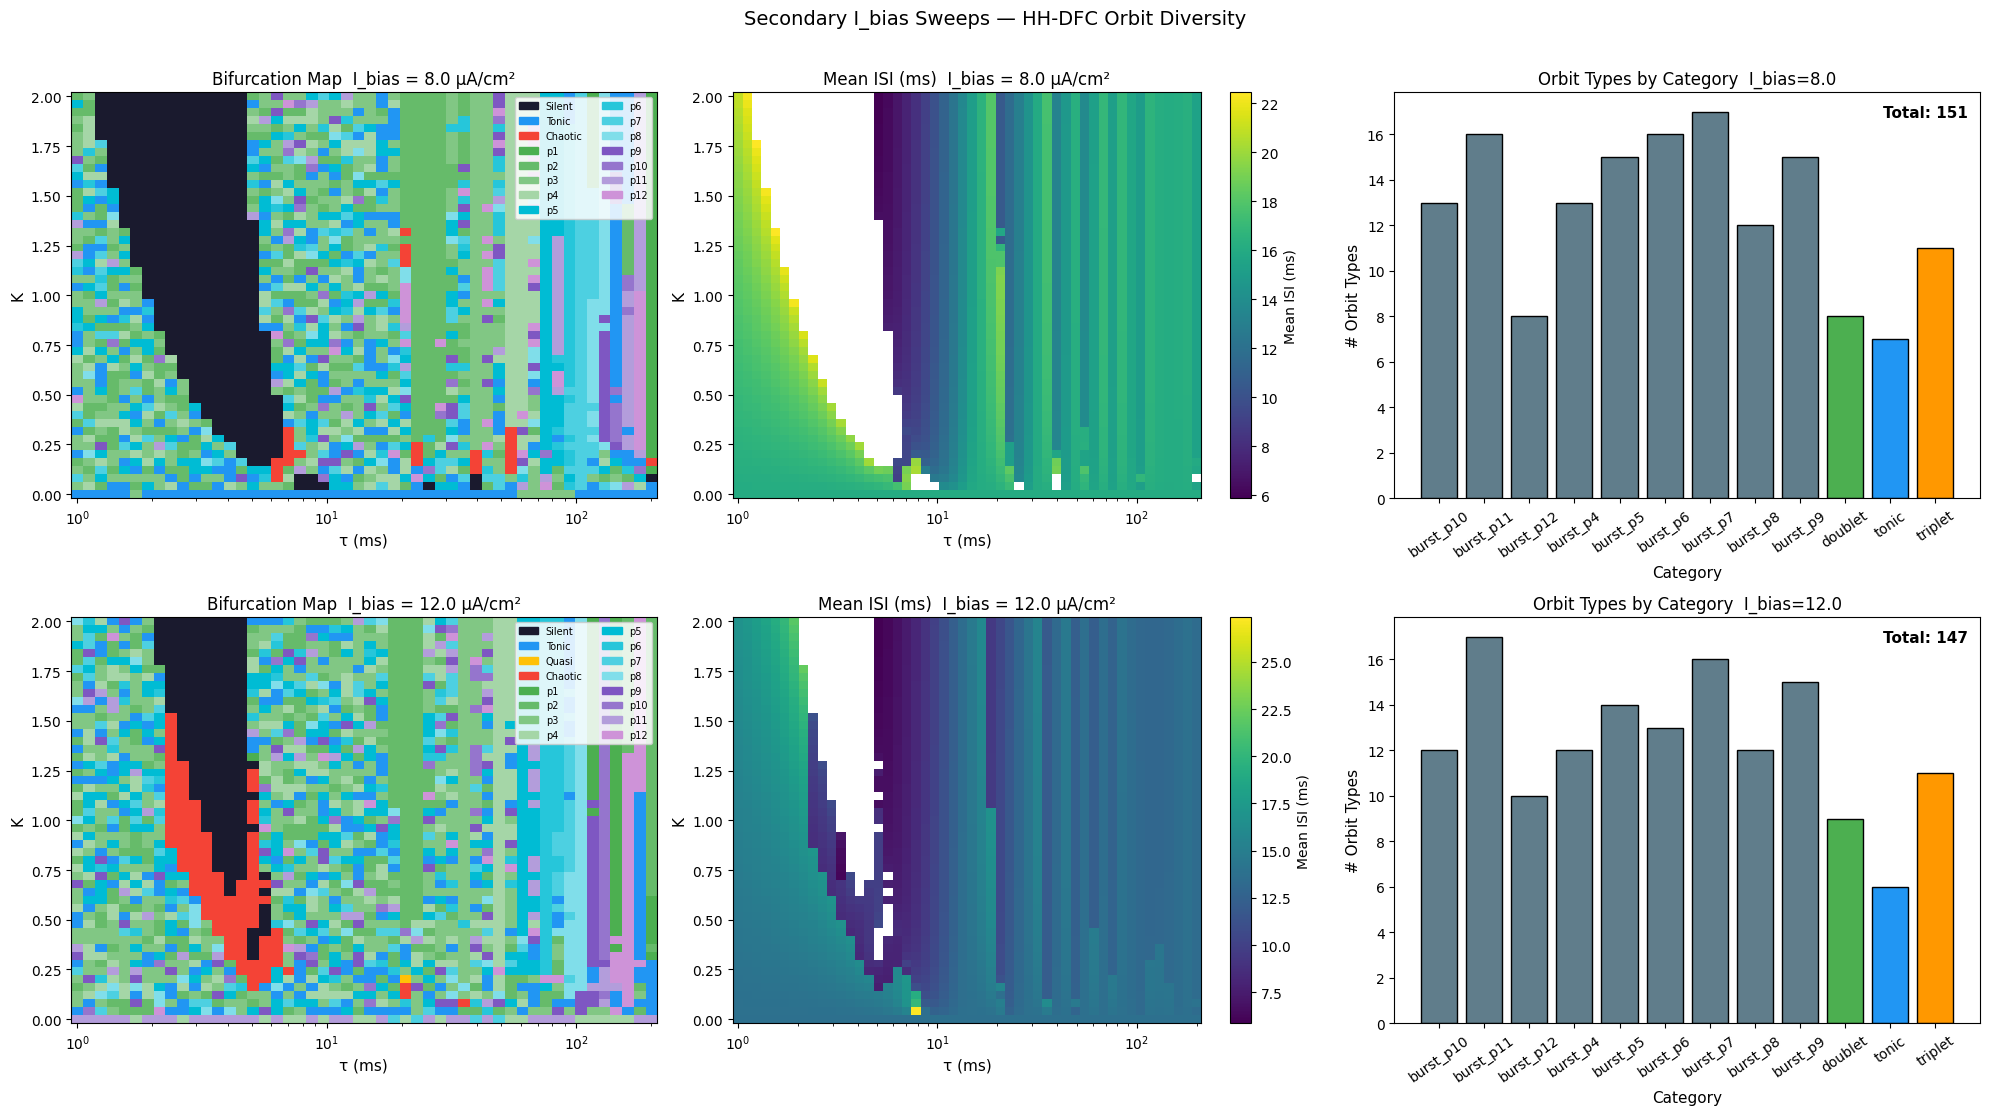


SECONDARY I_bias SWEEP — COMPARISON TABLE
    I_bias         Grid  Periodic%   #Types    #Categories     ISI range (ms)
---------------------------------------------------------------------------
10.0 (PS0)      101×100      85.9%      207             12           5.9–56.9
       8.0        51×50      80.9%      151             12           5.9–22.4
      12.0        51×50      87.4%      147             12           6.2–27.4
Notes:
  Primary PS0: 101×100 dense grid, T_sim=3000ms
  Secondary:    51×50  coarse grid, T_sim=3000ms (same classification logic)
  'Types' = orbit clusters at 2ms ISI linkage threshold

Combined summary saved: /content/drive/My Drive/HHSMC/full_study/PS0_secondary/PS0_secondary_summary.json

PS0_Secondary COMPLETE — ALL RESULTS SAVED
Output directory: /content/drive/My Drive/HHSMC/full_study/PS0_secondary
Files:
  PS0_secondary_Ibias_8p0.npz              — raw grid
  PS0_secondary_orbit_types_Ibias_8p0.json — orbit catalogue
  PS0_secondary_Ibias_12p0.npz     

In [9]:
if __name__ == '__main__' or True:

    print("="*70)
    print("PS0_Secondary — Secondary I_bias Sweeps")
    print("Option C: HH Delay-Directed Orbit Selection")
    print("="*70)

    # ── Grid definition ──────────────────────────────────────────────────────
    # Coarser than PS0 (51×50 vs 101×100) to keep runtime manageable.
    # Same K and τ bounds as PS0 to allow direct visual comparison.
    K_range   = np.arange(0.0, 2.04, 0.04)          # 51 values: 0.00, 0.04, ..., 2.00
    tau_range = np.geomspace(1.0, 200.0, 50)         # 50 log-spaced values

    print(f"Grid per bias: {len(K_range)} x {len(tau_range)} = "
          f"{len(K_range)*len(tau_range)} points")
    print(f"K:   {K_range[0]:.2f} to {K_range[-1]:.2f}  (step 0.04)")
    print(f"tau: {tau_range[0]:.1f} to {tau_range[-1]:.1f} ms (log-spaced)")

    # ── Bias values to sweep ──────────────────────────────────────────────────
    I_BIAS_VALUES = [8.0, 12.0]   # Add 7.0 or 15.0 here if desired

    all_results = []

    for I_bias in I_BIAS_VALUES:
        print("\n" + "="*60)
        print(f"SWEEP: I_bias = {I_bias:.1f} uA/cm2")
        print("="*60)

        # ── Run sweep ────────────────────────────────────────────────────────
        (results_grid, class_grid, isi_mean_grid, cv_grid, fr_grid,
         summary) = run_dense_sweep(I_bias, K_range, tau_range,
                                    T_sim=3000.0, T_transient=500.0)

        # ── Save raw grid ─────────────────────────────────────────────────────
        tag = f"Ibias_{str(I_bias).replace('.', 'p')}"
        npz_path = os.path.join(OUTPUT_DIR, f'PS0_secondary_{tag}.npz')
        np.savez_compressed(npz_path,
                            class_grid=class_grid,
                            isi_mean_grid=isi_mean_grid,
                            cv_grid=cv_grid,
                            fr_grid=fr_grid,
                            K_range=K_range,
                            tau_range=tau_range,
                            I_bias=np.array([I_bias]))
        print(f"Raw grid saved: {npz_path}")

        # ── Cluster orbits ────────────────────────────────────────────────────
        print(f"\nClustering orbits for I_bias = {I_bias:.1f}...")
        orbit_types, _ = cluster_orbits(results_grid, K_range, tau_range,
                                         min_isi_separation=2.0)

        # ── Save orbit catalogue ──────────────────────────────────────────────
        json_path = os.path.join(OUTPUT_DIR, f'PS0_secondary_orbit_types_{tag}.json')
        with open(json_path, 'w') as f:
            json.dump(clean_for_json(orbit_types), f, indent=2)
        print(f"Orbit catalogue saved: {json_path}")

        all_results.append({
            'I_bias': I_bias, 'tag': tag,
            'class_grid': class_grid, 'isi_mean_grid': isi_mean_grid,
            'K_range': K_range, 'tau_range': tau_range,
            'orbit_types': orbit_types, 'summary': summary,
        })

    # ── Comparison figure ─────────────────────────────────────────────────────
    print("\nGenerating comparison figure...")
    plot_comparison(all_results, save_dir=OUTPUT_DIR)

    # ── Comparison table ──────────────────────────────────────────────────────
    # Primary PS0 summary (hard-coded from PS0 output for reference)
    primary_summary = {
        'n_types': 207, 'n_categories': 12,
        'periodic_pct': 85.9,
        'isi_range': '5.9–56.9',
    }
    print_comparison_table(primary_summary, all_results)

    # ── Save combined summary JSON ────────────────────────────────────────────
    combined = {
        'primary': {'I_bias': 10.0, 'grid': '101x100',
                    'n_orbit_types': 207, 'n_categories': 12,
                    'periodic_pct': 85.9},
        'secondary': []
    }
    for res in all_results:
        s = res['summary']
        cc = s['class_counts']
        total = s['total_points']
        n_periodic = sum(v for k,v in cc.items()
                         if k == 'tonic' or k.startswith('periodic_p'))
        combined['secondary'].append({
            'I_bias': res['I_bias'],
            'grid': f"{s['n_K']}x{s['n_tau']}",
            'n_orbit_types': len(res['orbit_types']),
            'n_categories':  len(set(ot['category'] for ot in res['orbit_types'])),
            'periodic_pct':  round(100.0 * n_periodic / total, 1),
            'elapsed_s':     round(s['elapsed_s'], 1),
        })

    summary_path = os.path.join(OUTPUT_DIR, 'PS0_secondary_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(clean_for_json(combined), f, indent=2)
    print(f"\nCombined summary saved: {summary_path}")

    # ── Final report ──────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("PS0_Secondary COMPLETE — ALL RESULTS SAVED")
    print("="*70)
    print(f"Output directory: {OUTPUT_DIR}")
    print("Files:")
    for res in all_results:
        tag = res['tag']
        print(f"  PS0_secondary_{tag}.npz              — raw grid")
        print(f"  PS0_secondary_orbit_types_{tag}.json — orbit catalogue")
    print("  PS0_secondary_summary.json            — comparison table")
    print("  PS0_secondary_comparison.png          — 2x3 figure (paper-ready)")
    print("\nNext step: paste comparison table numbers into paper Section 5.6")